# KneeVision++ — Full Pipeline

Explainable multimodal AI for knee OA severity grading.

**Phases covered:**
1. Setup & Data Exploration
2. Model Training (DenseNet121 & EfficientNet-B4)
3. Model Comparison
4. Ensemble Evaluation (Cohen's Kappa, Confusion Matrix)
5. Explainable AI (Grad-CAM, Score-CAM, LIME)
6. Test-Time Augmentation

In [1]:
# --- Setup & imports ---
import sys, os
from pathlib import Path

# Detect Colab vs local
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # Adjust this path to where you placed the project
    PROJECT_ROOT = Path("/content/drive/MyDrive/KneeVision")
    !pip install torch torchvision numpy pillow tqdm scikit-learn matplotlib -q
else:
    PROJECT_ROOT = Path.cwd().parent
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "scikit-learn", "-q"], capture_output=True)

sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")
print(f"Working dir:  {os.getcwd()}")

Project root: /home/darshan/learning/ai/KneeVision
Working dir:  /home/darshan/learning/ai/KneeVision


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

from kneevision.config.settings import RAW_DATA_DIR, BATCH_SIZE, LEARNING_RATE, NUM_EPOCHS,\
    WEIGHT_DECAY, MAX_GRAD_NORM, LABEL_SMOOTHING, MIXUP_ALPHA, SAMPLER_POWER,\
    EARLY_STOP_PATIENCE, CHECKPOINT_INTERVAL
from kneevision.models.image_model import KneeXRayClassifier, AVAILABLE_MODELS
from kneevision.data.dataset import KneeXRayDataset, MixUpDataset, make_weighted_sampler
from kneevision.data.transforms import train_transform, minority_transform, val_transform, tta_transforms_list
from kneevision.training.trainer import train_epoch, validate, EMA, EarlyStopping, save_checkpoint, load_checkpoint
from kneevision.training.losses import FocalLoss, OrdinalLoss, ordinal_to_class
from kneevision.utils.helpers import set_seed, get_device
from kneevision.xai import gradcam, scorecam, lime

set_seed(42)
device = get_device()
IS_CUDA = device.type == 'cuda'

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {device}')
if IS_CUDA:
    print(f'GPU:     {torch.cuda.get_device_name(0)}')
    print(f'Memory:  {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GiB')
    print(f'CC:      {torch.cuda.get_device_capability(0)}')
    torch.cuda.empty_cache()
else:
    print('WARNING: No GPU detected - training will be slow on CPU.')
print(f'Data:    {RAW_DATA_DIR} (exists: {RAW_DATA_DIR.exists()})')


PyTorch: 2.13.0+cu130
Device:  cuda
GPU:     NVIDIA GeForce RTX 4050 Laptop GPU
Memory:  5.7 GiB
CC:      (8, 9)
Data:    /home/darshan/learning/ai/KneeVision/data/raw (exists: True)


---
## 1. Data Exploration

Train: 5778 images
Val:   826 images
Test:  1656 images


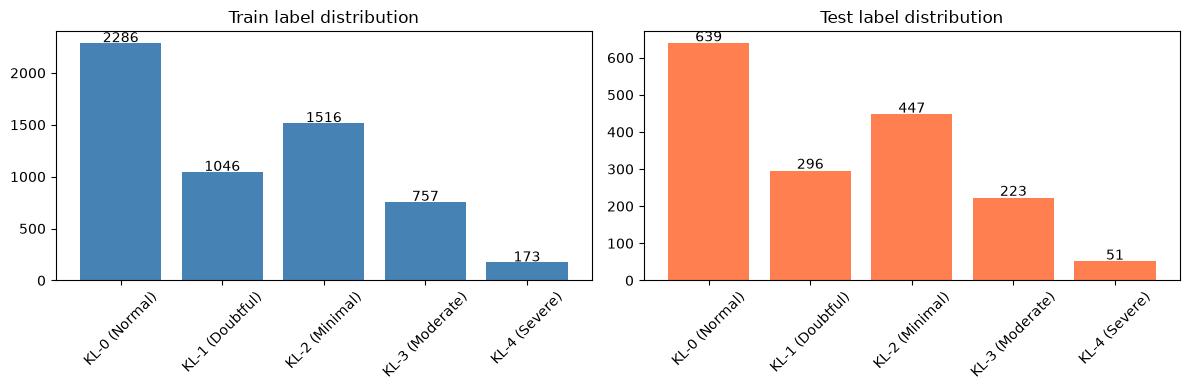

In [3]:
# --- Load dataset paths ---
def get_paths_and_labels(split: str):
    paths, labels = [], []
    split_dir = RAW_DATA_DIR / split
    if not split_dir.exists():
        raise FileNotFoundError(f"Data not found at {split_dir}")
    for grade_dir in sorted(split_dir.iterdir()):
        if not grade_dir.is_dir():
            continue
        label = int(grade_dir.name)
        for img_path in sorted(grade_dir.glob("*.png")):
            paths.append(img_path)
            labels.append(label)
    return paths, labels

train_paths, train_labels = get_paths_and_labels("train")
val_paths,   val_labels   = get_paths_and_labels("val")
test_paths,  test_labels  = get_paths_and_labels("test")

print(f"Train: {len(train_paths)} images")
print(f"Val:   {len(val_paths)} images")
print(f"Test:  {len(test_paths)} images")

# Label distribution
kl_names = ["KL-0 (Normal)", "KL-1 (Doubtful)", "KL-2 (Minimal)", "KL-3 (Moderate)", "KL-4 (Severe)"]
train_dist = [train_labels.count(i) for i in range(5)]
test_dist  = [test_labels.count(i) for i in range(5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(kl_names, train_dist, color="steelblue")
ax1.set_title("Train label distribution")
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(train_dist):
    ax1.text(i, v + 10, str(v), ha='center')

ax2.bar(kl_names, test_dist, color="coral")
ax2.set_title("Test label distribution")
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(test_dist):
    ax2.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()

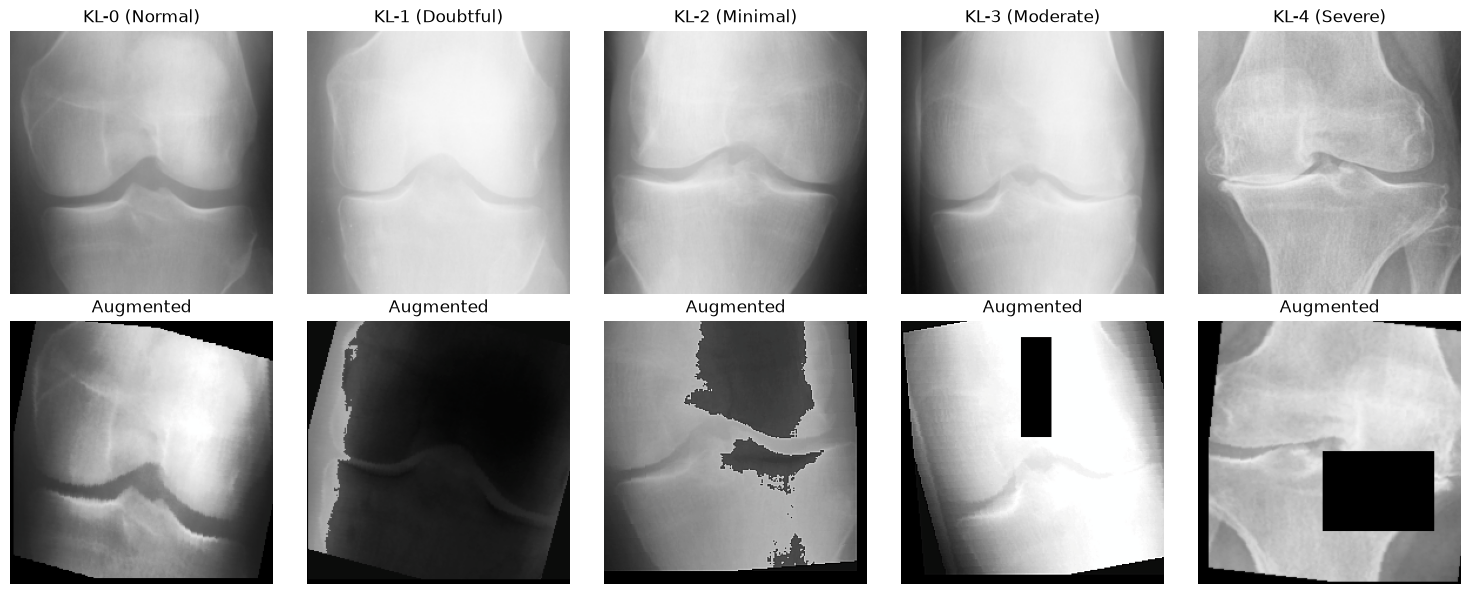

In [4]:
# Visualize a few X-ray samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for grade in range(5):
    idx = train_labels.index(grade)
    img = Image.open(train_paths[idx]).convert("RGB")
    axes[0, grade].imshow(img, cmap="gray")
    axes[0, grade].set_title(f"{kl_names[grade]}")
    axes[0, grade].axis("off")
    # Also show with augmentation
    aug = train_transform(img)
    aug_np = aug.permute(1, 2, 0).numpy()
    # Undo normalize for display
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    aug_np = np.clip(aug_np * std + mean, 0, 1)
    axes[1, grade].imshow(aug_np)
    axes[1, grade].set_title("Augmented")
    axes[1, grade].axis("off")
plt.tight_layout()
plt.show()

---
## 2. Training

In [5]:
# Create DataLoaders with MixUp, stronger class balancing, and minority augmentation
train_ds = KneeXRayDataset(
    train_paths, train_labels,
    transform=train_transform,
    minority_transform=minority_transform,
    minority_labels={3, 4},
)

if MIXUP_ALPHA > 0:
    train_ds = MixUpDataset(train_ds, alpha=MIXUP_ALPHA, num_classes=5)
    print(f'MixUp active (alpha={MIXUP_ALPHA})')

val_ds = KneeXRayDataset(val_paths, val_labels, val_transform)
sampler = make_weighted_sampler(train_labels, power=SAMPLER_POWER)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=2, pin_memory=IS_CUDA)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=IS_CUDA)


MixUp active (alpha=0.4)


In [6]:
# Class weights for FocalLoss
class_counts = torch.tensor([train_labels.count(i) for i in range(5)], dtype=torch.float)
class_weights = (1.0 / class_counts) * class_counts.sum() / 5
print(f'Class counts: {class_counts.tolist()}')
print(f'Class weights: {class_weights.tolist()}')


Class counts: [2286.0, 1046.0, 1516.0, 757.0, 173.0]
Class weights: [0.5055118203163147, 1.1047800779342651, 0.762269139289856, 1.5265522003173828, 6.6797685623168945]


In [7]:
def train_model(model_name: str, num_epochs: int = NUM_EPOCHS,
                 use_focal: bool = True, ordinal: bool = False,
                 resume: bool = False):
    mode = 'Ordinal' if ordinal else 'FocalLoss' if use_focal else 'CrossEntropy'
    print('\n' + '='*60)
    print(f'Training: {model_name}  |  {mode}')
    print('='*60)

    model = KneeXRayClassifier(model_name, 5, ordinal=ordinal).to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f'Parameters: {params:,}')

    if ordinal:
        criterion = OrdinalLoss(num_classes=5)
    elif use_focal:
        criterion = FocalLoss(alpha=class_weights.to(device),
                              gamma=2.0, label_smoothing=LABEL_SMOOTHING)
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    warmup_epochs = 5
    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / warmup_epochs
        return 0.5 * (1 + torch.cos(torch.tensor(
            (ep - warmup_epochs) / (num_epochs - warmup_epochs) * 3.14159)))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    ema = EMA(model, decay=0.995)
    early_stop = EarlyStopping(patience=EARLY_STOP_PATIENCE)
    scaler = torch.amp.GradScaler('cuda') if IS_CUDA else None

    save_dir = PROJECT_ROOT / 'models'
    save_dir.mkdir(exist_ok=True)
    suffix = '_ordinal' if ordinal else ''
    best_path = save_dir / f'best_{model_name}{suffix}.pt'
    ckpt_path = save_dir / f'checkpoint_{model_name}{suffix}.pt'

    history = {'train_loss': [], 'val_loss': [], 'val_kappa': [],
               'ema_kappa': [], 'val_acc': []}
    start_epoch = 1
    best_kappa = -1.0

    if resume and ckpt_path.exists():
        ep, bk, hist = load_checkpoint(ckpt_path, model, optimizer, scheduler, ema, early_stop)
        start_epoch = ep + 1
        best_kappa = bk
        history = hist
        model = model.to(device)
        print(f'Resumed from epoch {ep} (best kappa={best_kappa:.4f})')

    for epoch in range(start_epoch, num_epochs + 1):
        model.train()
        total_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch}'):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            if scaler:
                with torch.amp.autocast('cuda'):
                    loss = criterion(model(images), labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss = criterion(model(images), labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
            ema.update(model)
            total_loss += loss.item()
        train_loss = total_loss / len(train_loader)

        val_loss, val_kappa = validate(model, val_loader, criterion, device, use_kappa=True)
        _, ema_kappa = validate(ema.model, val_loader, criterion, device, use_kappa=True)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_kappa'].append(val_kappa)
        history['ema_kappa'].append(ema_kappa)
        history['val_acc'].append(val_kappa)

        if IS_CUDA:
            mem = f' | GPU: {torch.cuda.max_memory_allocated()/1024**3:.2f} GiB'
        else:
            mem = ''
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:2d}/{num_epochs} | LR {lr:.2e} | '
              f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
              f'Kappa: {val_kappa:.4f} | EMA: {ema_kappa:.4f}{mem}')

        best = max(val_kappa, ema_kappa)
        if best > best_kappa:
            best_kappa = best
            ckpt = ema.state_dict() if ema_kappa >= val_kappa else model.state_dict()
            torch.save(ckpt, best_path)
            print(f'  -> Saved best (kappa={best:.4f})')

        if epoch % CHECKPOINT_INTERVAL == 0:
            save_checkpoint(ckpt_path, model, optimizer, scheduler, ema,
                           early_stop, epoch, best_kappa, history, model_name, ordinal)

        if early_stop.step(best):
            print(f'  Early stopping (no improvement for {EARLY_STOP_PATIENCE} epochs)')
            save_checkpoint(ckpt_path, model, optimizer, scheduler, ema,
                           early_stop, epoch, best_kappa, history, model_name, ordinal)
            break

        if IS_CUDA:
            torch.cuda.reset_peak_memory_stats()

    # Save final checkpoint
    save_checkpoint(ckpt_path, model, optimizer, scheduler, ema,
                   early_stop, epoch, best_kappa, history, model_name, ordinal)
    print(f'Finished {model_name} | Best kappa: {best_kappa:.4f}')
    return model, ema, history, best_kappa, params


In [8]:
# Train models (set num_epochs to small value for quick testing)
# For full training, use NUM_EPOCHS (100)
N_EPOCHS = 50  # Change to NUM_EPOCHS for full training

# Set resume=True to pick up from a previous checkpoint
results = {}
for name in ['densenet121']:
    model, ema, history, best_kappa, params = train_model(
        name, num_epochs=N_EPOCHS, use_focal=True, ordinal=True, resume=False)
    results[name] = {'model': model, 'ema': ema,
                     'history': history, 'best_kappa': best_kappa, 'params': params}

# To add more architectures:
# for name in ['densenet121', 'convnext_tiny', 'vit_b_16', 'swin_t']:
# To resume a stopped run, change resume=False to resume=True



Training: densenet121  |  Ordinal
Parameters: 8,009,604


Validation: 100%|██████████| 26/26 [00:07<00:00,  3.60it/s]


Epoch  1/50 | LR 4.00e-05 | Train Loss: 0.6133 | Val Loss: 0.5307 | Kappa: 0.1374 | EMA: -0.0046 | GPU: 2.17 GiB
  -> Saved best (kappa=0.1374)


Validation: 100%|██████████| 26/26 [00:07<00:00,  3.55it/s]


Epoch  2/50 | LR 6.00e-05 | Train Loss: 0.4475 | Val Loss: 0.4675 | Kappa: 0.2807 | EMA: 0.2215 | GPU: 2.17 GiB
  -> Saved best (kappa=0.2807)


...

Epoch 34/50 | LR 2.81e-05 | Train Loss: 0.2634 | Val Loss: 0.3162 | Kappa: 0.7583 | EMA: 0.3202 | GPU: 2.17 GiB


Validation: 100%|██████████| 26/26 [00:06<00:00,  3.72it/s]


Epoch 35/50 | LR 2.50e-05 | Train Loss: 0.2578 | Val Loss: 0.3191 | Kappa: 0.7519 | EMA: 0.3403 | GPU: 2.17 GiB
  Checkpoint saved to /home/darshan/learning/ai/KneeVision/models/checkpoint_densenet121_ordinal.pt


Validation: 100%|██████████| 26/26 [00:06<00:00,  3.76it/s]


Epoch 36/50 | LR 2.20e-05 | Train Loss: 0.2566 | Val Loss: 0.3077 | Kappa: 0.7545 | EMA: 0.2614 | GPU: 2.17 GiB
  Early stopping (no improvement for 15 epochs)
  Checkpoint saved to /home/darshan/learning/ai/KneeVision/models/checkpoint_densenet121_ordinal.pt
  Checkpoint saved to /home/darshan/learning/ai/KneeVision/models/checkpoint_densenet121_ordinal.pt
Finished densenet121 | Best kappa: 0.7870


---
## 3. Training Curves

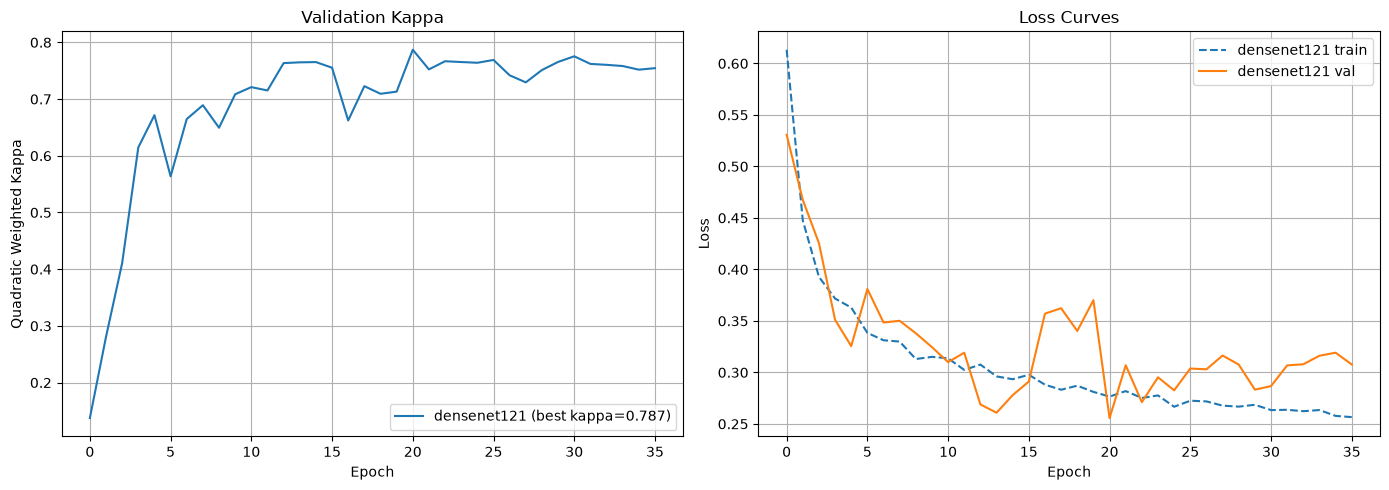


------------------------------------------------
Model                |     Params |   Best Kappa
------------------------------------------------
densenet121          |  8,009,604 |       0.7870


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    h = res['history']
    axes[0].plot(h['val_kappa'], label=f"{name} (best kappa={res['best_kappa']:.3f})")
    axes[1].plot(h['train_loss'], '--', label=f'{name} train')
    axes[1].plot(h['val_loss'], '-', label=f'{name} val')

axes[0].set_title('Validation Kappa')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Quadratic Weighted Kappa')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Comparison table
print('\n' + '-'*48)
print(f"{'Model':<20} | {'Params':>10} | {'Best Kappa':>12}")
print('-'*48)
for name, res in results.items():
    print(f"{name:<20} | {res['params']:>10,} | {res['best_kappa']:>12.4f}")


---
## 4. Ensemble Evaluation on Test Set

In [24]:
# Load best saved models for ensemble evaluation
test_ds = KneeXRayDataset(test_paths, test_labels, val_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=IS_CUDA)
print(f"Test samples: {len(test_ds)}")

Test samples: 1656


In [25]:
from torchvision.transforms import functional as TF
from kneevision.training.trainer import load_checkpoint

def apply_tta(img_tensor, tta_tfm):
    return tta_tfm(TF.to_pil_image(img_tensor.cpu()))

@torch.inference_mode()
def ensemble_predict(models, loader, device, use_tta=True):
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in tqdm(loader, desc='Ensemble'):
        images = images.to(device)
        probs = torch.zeros(len(images), 5, device=device)
        for model in models:
            model.eval()
            if use_tta:
                tta_probs = []
                for tta_tfm in tta_transforms_list:
                    tta_imgs = torch.stack(
                        [apply_tta(im, tta_tfm) for im in images]
                    ).to(device)
                    logits = model(tta_imgs)
                    if getattr(model, 'ordinal', False):
                        preds = ordinal_to_class(logits)
                        p = torch.zeros(len(images), 5, device=device)
                        for c in range(5):
                            p[:, c] = (preds == c).float()
                    else:
                        p = F.softmax(logits, dim=1)
                    tta_probs.append(p)
                probs += torch.stack(tta_probs).mean(dim=0)
            else:
                logits = model(images)
                if getattr(model, 'ordinal', False):
                    preds = ordinal_to_class(logits)
                    for c in range(5):
                        probs[:, c] = (preds == c).float()
                else:
                    probs += F.softmax(logits, dim=1)
        probs /= len(models)
        all_preds.extend(probs.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.tolist())
        all_probs.extend(probs.cpu().numpy())
    return all_preds, all_labels, np.array(all_probs)

def _fix_checkpoint_keys(sd):
    # Remap old classifier keys (classifier.0 -> classifier.net.0)
    keys = list(sd.keys())
    for k in keys:
        if k.startswith('classifier.') and not k.startswith('classifier.net.'):
            new_k = 'classifier.net.' + k[len('classifier.'):]
            sd[new_k] = sd.pop(k)
    return sd

# Load models from checkpoints or use in-memory
ensemble_models = []
for name in ['densenet121']:
    # Try ordinal first (new format), then standard (old format)
    for suffix in ['_ordinal', '']:
        path = Path(f'models/best_{name}{suffix}.pt')
        if path.exists():
            sd = torch.load(path, map_location=device, weights_only=True)
            sd = _fix_checkpoint_keys(sd)
            classifier_weights = [v for k, v in sd.items()
                                  if 'classifier.net' in k and 'weight' in k]
            last_w = classifier_weights[-1]
            is_ord = last_w.shape[0] == 4
            m = KneeXRayClassifier(name, 5, ordinal=is_ord).to(device)
            m.load_state_dict(sd)
            ensemble_models.append(m)
            tag = 'ordinal' if is_ord else 'standard'
            print(f'Loaded {name} ({tag}) from {path}')
            break
    else:
        if name in results:
            m = results[name].get('ema') or results[name]['model']
            ensemble_models.append(m)
            print(f'Using in-memory {name}')
        else:
            print(f'Warning: {name} not available')

if ensemble_models:
    preds, labels, probs = ensemble_predict(
        ensemble_models, test_loader, device, use_tta=True
    )



Loaded densenet121 (ordinal) from models/best_densenet121_ordinal.pt


Ensemble: 100%|██████████| 52/52 [00:24<00:00,  2.17it/s]



CLASSIFICATION REPORT (with TTA)
                 precision    recall  f1-score   support

  KL-0 (Normal)     0.0000    0.0000    0.0000       639
KL-1 (Doubtful)     0.0000    0.0000    0.0000       296
 KL-2 (Minimal)     0.0000    0.0000    0.0000       447
KL-3 (Moderate)     0.1022    0.6502    0.1766       223
  KL-4 (Severe)     0.1139    0.5294    0.1875        51

       accuracy                         0.1039      1656
      macro avg     0.0432    0.2359    0.0728      1656
   weighted avg     0.0173    0.1039    0.0296      1656

Cohen's Kappa (quadratic): 0.0453

Confusion Matrix:
          KL-      0KL-      1KL-      2KL-      3KL-      4
Actual KL-   0       0       0       0     594      45
Actual KL-   1       0       0       0     268      28
Actual KL-   2       0       0       0     388      59
Actual KL-   3       0       0       0     145      78
Actual KL-   4       0       0       0      24      27


/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

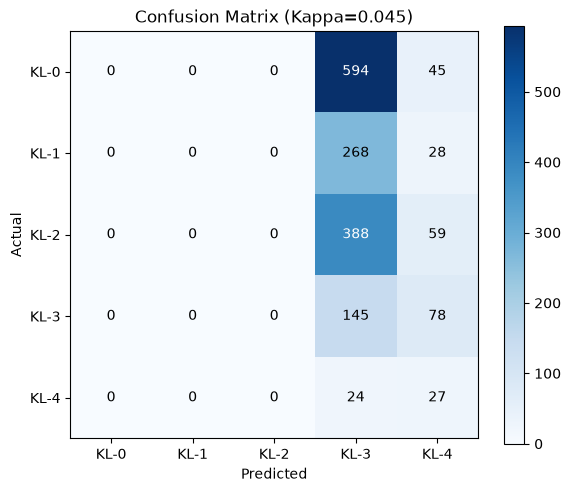

In [26]:
if ensemble_models:
    print("\n" + "="*65)
    print("CLASSIFICATION REPORT (with TTA)")
    print("="*65)
    print(classification_report(labels, preds,
          target_names=kl_names, digits=4))

    kappa = cohen_kappa_score(labels, preds, weights='quadratic')
    print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

    cm = confusion_matrix(labels, preds)
    print("\nConfusion Matrix:")
    print(' ' * 10, end='')
    for i in range(5):
        print(f'KL-{i:>7}', end='')
    print()
    for i in range(5):
        print(f'Actual KL-{i:>4}', end='')
        for j in range(5):
            print(f'{cm[i,j]:>8}', end='')
        print()

    # Confusion matrix heatmap
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels([f'KL-{i}' for i in range(5)])
    ax.set_yticklabels([f'KL-{i}' for i in range(5)])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    for i in range(5):
        for j in range(5):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center',
                    va='center', color=color)
    plt.colorbar(im)
    plt.title(f'Confusion Matrix (Kappa={kappa:.3f})')
    plt.tight_layout()
    plt.show()
else:
    print('No models available for evaluation.')


---
## 5. Explainable AI (XAI)

In [33]:
# Pick a sample from each KL grade for visualization
def get_sample_by_grade(paths, labels, grade):
    idx = labels.index(grade)
    return Image.open(paths[idx]).convert("RGB"), labels[idx]

samples = [get_sample_by_grade(test_paths, test_labels, g) for g in range(5)]

# Use the first trained model for XAI
xai_model_name = list(results.keys())[0]
xai_model = results[xai_model_name]["model"]
print(f"Using {xai_model_name} for explanations")

Using densenet121 for explanations


IndexError: invalid index to scalar variable.

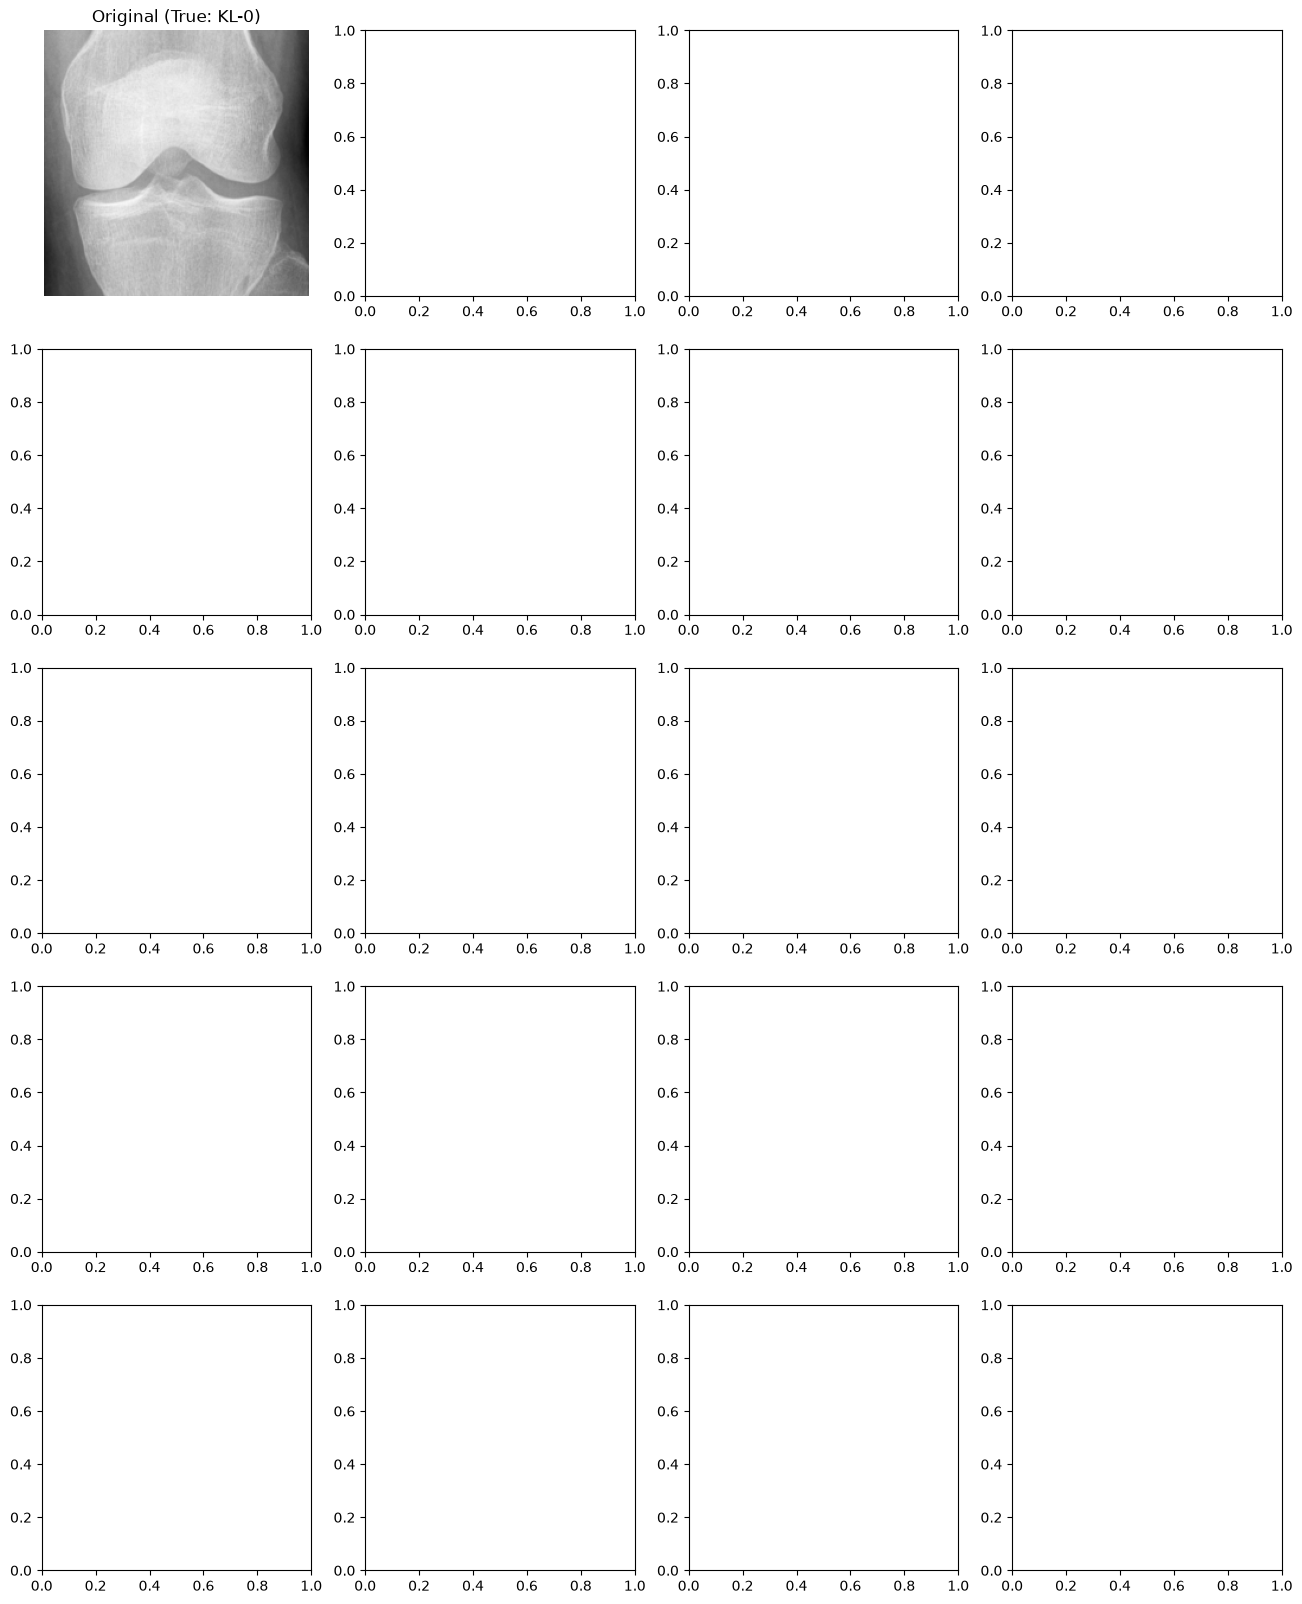

In [34]:
# Generate Grad-CAM, Score-CAM, and LIME explanations
fig, axes = plt.subplots(5, 4, figsize=(16, 20))

for row, (img, true_label) in enumerate(samples):
    # Original
    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_title(f"Original (True: KL-{true_label})")
    axes[row, 0].axis("off")

    # Grad-CAM
    pred_gc, conf_gc, overlay_gc = gradcam.explain(xai_model, img, val_transform, device)
    axes[row, 1].imshow(overlay_gc)
    axes[row, 1].set_title(f"Grad-CAM\nPred: KL-{pred_gc} | {conf_gc:.2%}")
    axes[row, 1].axis("off")

    # Score-CAM
    pred_sc, conf_sc, overlay_sc = scorecam.explain(xai_model, img, val_transform, device)
    axes[row, 2].imshow(overlay_sc)
    axes[row, 2].set_title(f"Score-CAM\nPred: KL-{pred_sc} | {conf_sc:.2%}")
    axes[row, 2].axis("off")

    # LIME
    pred_li, conf_li, importance, segments = lime.explain(xai_model, img, val_transform, device)
    axes[row, 3].imshow(importance, cmap="Reds", alpha=0.7)
    axes[row, 3].imshow(np.array(img.resize((224, 224))) / 255.0, alpha=0.3)
    axes[row, 3].set_title(f"LIME\nPred: KL-{pred_li} | {conf_li:.2%}")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

---
## 6. Test-Time Augmentation (TTA)

In [29]:
# Compare standard vs TTA prediction on a single image
img, true_label = get_sample_by_grade(test_paths, test_labels, 2)

# Standard prediction
x = val_transform(img).unsqueeze(0).to(device)
with torch.inference_mode():
    logits = xai_model(x)
    probs = F.softmax(logits, dim=1)
    std_pred = probs.argmax(dim=1).item()
    std_conf = probs[0, std_pred].item()

# TTA prediction
tta_pred, tta_conf = tta_predict(xai_model, img, device)

print(f"True label: KL-{true_label}")
print(f"Standard  -> KL-{std_pred}  (confidence: {std_conf:.2%})")
print(f"TTA       -> KL-{tta_pred}  (confidence: {tta_conf:.2%})")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].bar(range(5), probs.squeeze().cpu().numpy(), color="steelblue")
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([f"KL-{i}" for i in range(5)])
axes[0].set_title(f"Standard Pred: KL-{std_pred}")
axes[0].set_ylabel("Probability")

# Get TTA probabilities
tta_probs = torch.zeros(5, device=device)
for tta_tfm in tta_transforms_list:
    x_tta = tta_tfm(img).unsqueeze(0).to(device)
    with torch.inference_mode():
        tta_probs += F.softmax(xai_model(x_tta), dim=1).squeeze()
tta_probs /= len(tta_transforms_list)

axes[1].bar(range(5), tta_probs.cpu().numpy(), color="coral")
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([f"KL-{i}" for i in range(5)])
axes[1].set_title(f"TTA Pred: KL-{tta_pred}")
axes[1].set_ylabel("Probability")
plt.tight_layout()
plt.show()

NameError: name 'tta_predict' is not defined

---
## 7. Per-Class Performance Analysis

/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

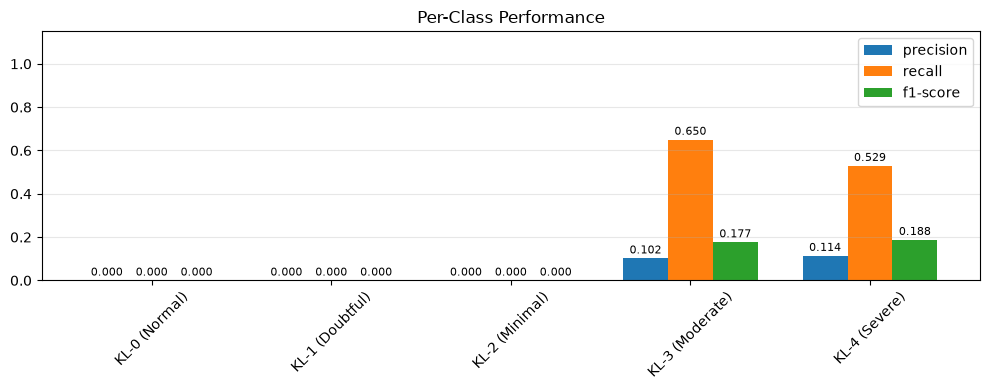

In [30]:
if ensemble_models:
    report = classification_report(labels, preds, target_names=kl_names, digits=4, output_dict=True)

    metrics = ["precision", "recall", "f1-score"]
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(kl_names))
    width = 0.25
    for i, metric in enumerate(metrics):
        values = [report[kl][metric] for kl in kl_names]
        bars = ax.bar(x + i * width, values, width, label=metric)
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{v:.3f}",
                    ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(kl_names, rotation=45)
    ax.set_ylim(0, 1.15)
    ax.legend()
    ax.set_title("Per-Class Performance")
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No predictions to analyze.")

---
## 8. Using a Custom Dataset

You can use any knee X-ray dataset. Supported formats:

### Format 1: Folder-based (current)
```
data/raw/
  train/
    0/  img1.png
    1/  img2.png
    2/  ...
    3/
    4/
  val/    (same structure)
  test/   (same structure)
```

### Format 2: CSV-based (flexible)
Create a CSV with columns: `filename,label,split`
```
filename,label,split
img_001.png,0,train
img_002.png,2,train
img_003.png,4,test
```

### OAI Dataset
Download from [nda.nih.gov/oai](https://nda.nih.gov/oai) (requires registration).
Place X-ray images in `data/raw/` then run the cell below to prepare.

In [ ]:
# --- Load any dataset ---
# Option A: Folder-based (default)
from kneevision.data.prepare import prepare_from_folders, print_split_summary

splits = prepare_from_folders(RAW_DATA_DIR)
print_split_summary(splits)
train_paths, train_labels = splits["train"]
val_paths,   val_labels   = splits.get("val", ([], []))
test_paths,  test_labels  = splits.get("test", ([], []))

# Option B: CSV-based (uncomment and adjust)
# from kneevision.data.prepare import prepare_from_csv
# splits = prepare_from_csv(Path("data/labels.csv"), RAW_DATA_DIR)
# ...

# Option C: Custom data — just point to folders
# import shutil
# CUSTOM_DATA = Path("/path/to/your/knee_xrays")
#     for f in (CUSTOM_DATA / str(grade)).glob("*.png"):
#         shutil.copy2(f, RAW_DATA_DIR / "train" / str(grade) / f.name)

---
## Summary

| Section | Description |
|---|---|
| **Data Exploration** | Label distribution, sample visualization |
| **Training** | DenseNet121 & EfficientNet-B4 with Focal Loss, Cosine Annealing |
| **Evaluation** | Ensemble classifier, Cohen's Kappa, Confusion Matrix |
| **XAI** | Grad-CAM, Score-CAM, LIME heatmap overlays |
| **TTA** | Test-Time Augmentation for more robust predictions |

**Next phases (coming):** Clinical text processing (BioClinicalBERT), multimodal fusion, RAG rehab system, FastAPI + React frontend.